Bounding boxes

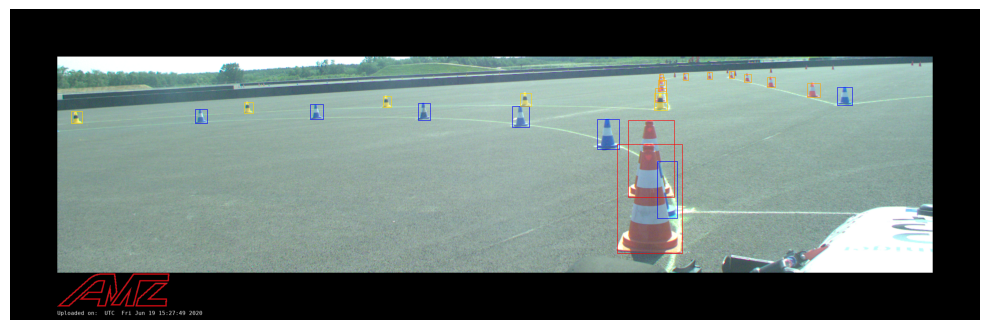

In [1]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


Image_DIR = "Images"
Ann_DIR = "Ann"
Image_Name = "amz_01961.png"

ann_path = os.path.join(Ann_DIR, Image_Name + ".json")
img_path = os.path.join(Image_DIR, Image_Name)

img = Image.open(img_path)

with open(ann_path, "r") as f:
    ann = json.load(f)


fig, ax = plt.subplots(1, figsize=(10, 10))
ax.imshow(img)
 
# Optional: assign a distinct color per class
color_map = {
    "blue_cone": "blue",
    "yellow_cone": "gold",
    "orange_cone": "orange",
}
color_cycle = plt.cm.tab10.colors
 
def get_color(class_title):
    return color_map.get(class_title, "red")
 
for obj in ann.get("objects", []):
    if obj.get("geometryType") != "rectangle":
        continue  # skip non-box shapes (polygons, points, etc.)
 
    (x1, y1), (x2, y2) = obj["points"]["exterior"]
    width = x2 - x1
    height = y2 - y1
    class_title = obj.get("classTitle", "")
    color = get_color(class_title)
 
    rect = patches.Rectangle(
        (x1, y1), width, height,
        linewidth=0.4, edgecolor=color, facecolor="none"
    )
    ax.add_patch(rect)
 
ax.axis("off")
plt.tight_layout()
plt.show()

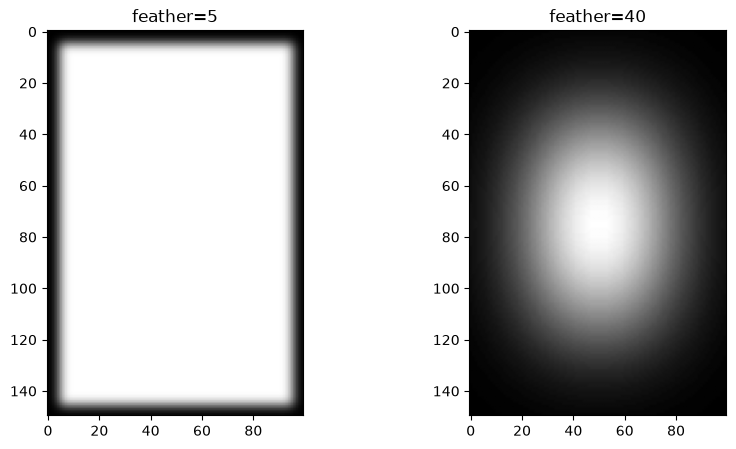

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageFilter, ImageDraw

patch_size = (100, 150)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, feather in zip(axes, [5, 40]):
    inner = Image.new("L", patch_size, 0)
    draw = ImageDraw.Draw(inner)
    draw.rectangle(
        [feather, feather, patch_size[0] - feather, patch_size[1] - feather],
        fill=255
    )
    mask = inner.filter(ImageFilter.GaussianBlur(feather // 2))
    ax.imshow(mask, cmap="gray")
    ax.set_title(f"feather={feather}")

plt.show()

Testing SAM on 13 cones (filtered from 50 total)


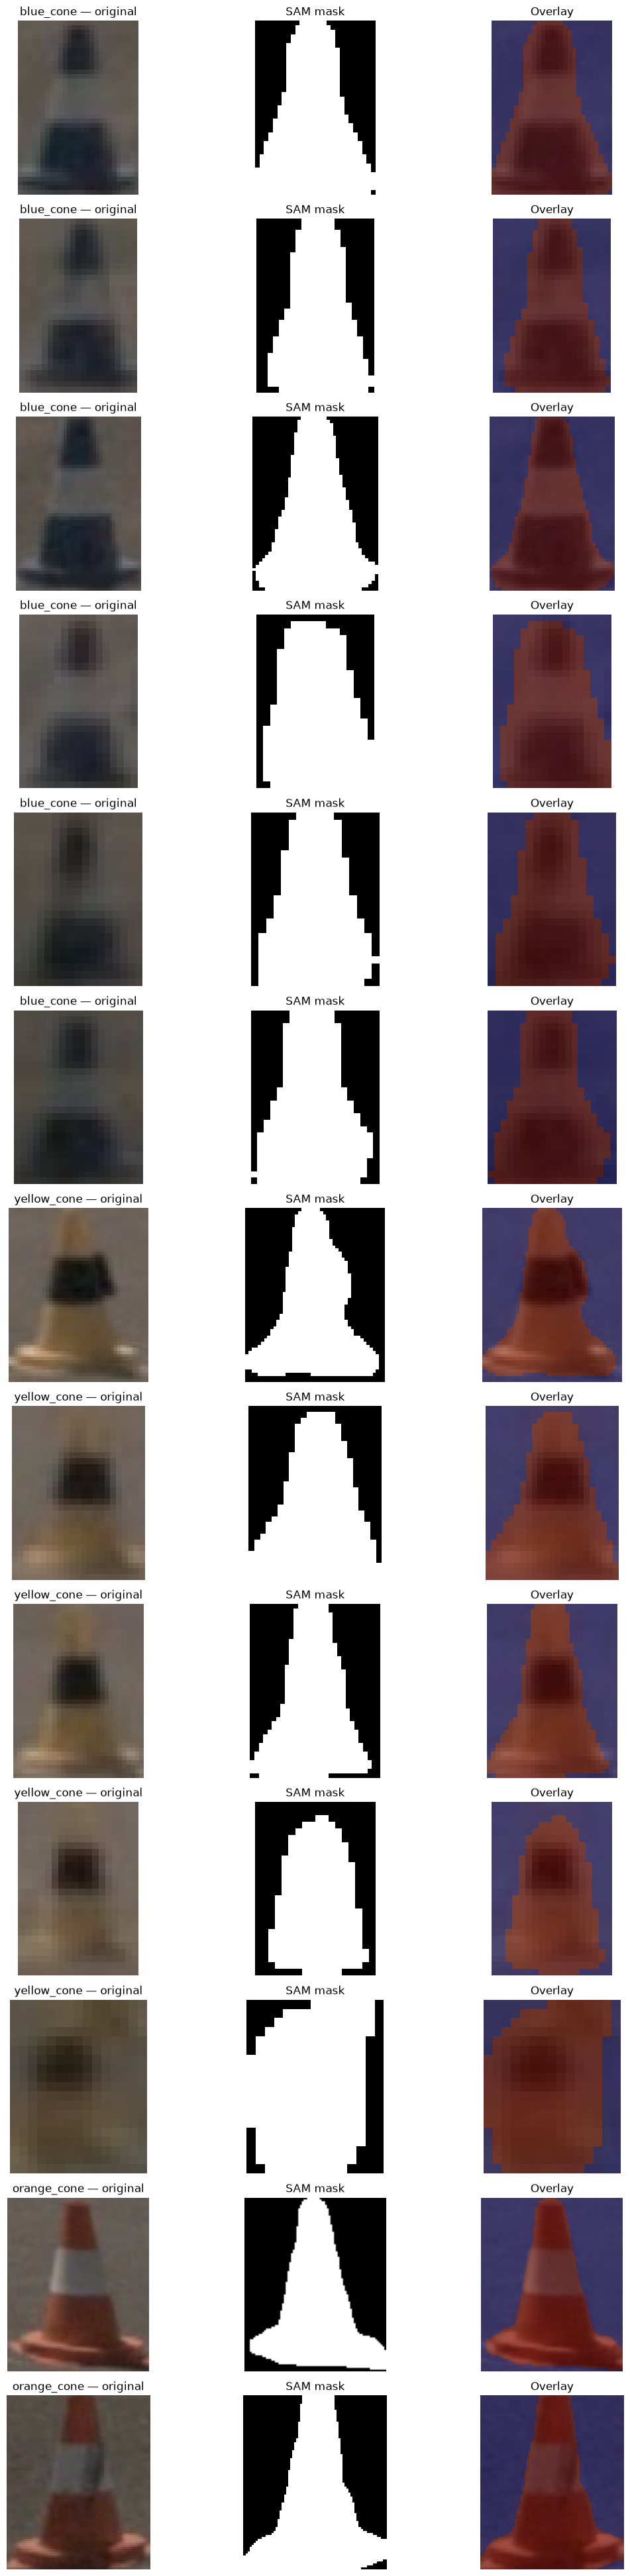

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor
from PIL import Image
import json

pref_size = 15  # match your main script

def load_cone_boxes(ann_path):
    with open(ann_path) as f:
        ann = json.load(f)
    boxes = []
    for obj in ann["objects"]:
        if obj["geometryType"] != "rectangle":
            continue
        (x0, y0), (x1, y1) = obj["points"]["exterior"]
        boxes.append((obj["classTitle"], (x0, y0, x1, y1)))
    return boxes

def is_big_enough(box, min_size=pref_size):
    x0, y0, x1, y1 = box
    width = x1 - x0
    height = y1 - y0
    return width >= min_size and height >= min_size

# Load SAM once
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device="cuda")
predictor = SamPredictor(sam)

# Load your real image + real boxes
image = Image.open("Images/amz_00000.jpg").convert("RGB")
image_np = np.array(image)
ann = load_cone_boxes("Ann/amz_00000.jpg.json")

valid_boxes = [(cls, box) for cls, box in ann if is_big_enough(box, min_size=pref_size)]
test_boxes = valid_boxes

print(f"Testing SAM on {len(test_boxes)} cones (filtered from {len(ann)} total)")

predictor.set_image(image_np)

fig, axes = plt.subplots(len(test_boxes), 3, figsize=(12, 3 * len(test_boxes)))

for row, (cls, box) in enumerate(test_boxes):
    x0, y0, x1, y1 = box
    box_arr = np.array([x0, y0, x1, y1])

    masks, scores, _ = predictor.predict(box=box_arr, multimask_output=False)
    mask = masks[0]

    crop = image.crop((x0, y0, x1, y1))
    mask_crop = mask[y0:y1, x0:x1]

    axes[row, 0].imshow(crop)
    axes[row, 0].set_title(f"{cls} — original")
    axes[row, 1].imshow(mask_crop, cmap="gray")
    axes[row, 1].set_title("SAM mask")
    axes[row, 2].imshow(crop)
    axes[row, 2].imshow(mask_crop, cmap="jet", alpha=0.4)
    axes[row, 2].set_title("Overlay")

    for c in range(3):
        axes[row, c].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import cv2
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

# CONFIG -------------------
IMAGE_NAME = "amz_00820.png"
IN_DIR = "masks"
CONE_INDEX = 0  # which cone to inspect

ERODE_PX = 0
BLUR_RADIUS = 0.02
# ---------------------------

import json

with open(f"{IN_DIR}/{IMAGE_NAME}_metadata.json") as f:
    meta = json.load(f)

cone = meta["cones"][CONE_INDEX]
box = tuple(cone["box"])
x0, y0, x1, y1 = box

image = Image.open(f"Images/{meta['image_name']}").convert("RGB")
crop = image.crop(box)

raw_mask = Image.open(f"{IN_DIR}/{meta['image_name']}_mask_{CONE_INDEX}.png")

# --- Eroded mask ---
mask_np = np.array(raw_mask)
kernel = np.ones((ERODE_PX * 2 + 1, ERODE_PX * 2 + 1), np.uint8)
eroded_np = cv2.erode(mask_np, kernel)
eroded_mask = Image.fromarray(eroded_np, mode="L")

# --- Eroded + blurred mask (final feathered mask) ---
feathered_mask = eroded_mask.filter(ImageFilter.GaussianBlur(BLUR_RADIUS))

# --- Visualize ---
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(crop)
axes[0].set_title("Cone crop")

axes[1].imshow(raw_mask, cmap="gray")
axes[1].set_title("Raw SAM mask")

axes[2].imshow(eroded_mask, cmap="gray")
axes[2].set_title(f"Eroded ({ERODE_PX}px)")

axes[3].imshow(feathered_mask, cmap="gray")
axes[3].set_title(f"Blurred ({BLUR_RADIUS}px radius)")

# Overlay: show the blend zone (where mask value is neither 0 nor 255) in red
feathered_np = np.array(feathered_mask)
blend_zone = ((feathered_np > 5) & (feathered_np < 250)).astype(np.uint8) * 255
overlay = np.array(crop).copy()
overlay[blend_zone > 0] = [255, 0, 0]  # red = blend zone
axes[4].imshow(overlay)
axes[4].set_title("Blend zone (red)")

for ax in axes:
    ax.axis("off")

box_w, box_h = x1 - x0, y1 - y0
fig.suptitle(f"Cone {CONE_INDEX} — box size {box_w}x{box_h}px | erode={ERODE_PX}px blur={BLUR_RADIUS}px")
plt.tight_layout()
plt.savefig(f"debug_feather_cone{CONE_INDEX}.png", dpi=150)
plt.show()
print(f"Saved debug_feather_cone{CONE_INDEX}.png")

TypeError: 'float' object cannot be interpreted as an integer

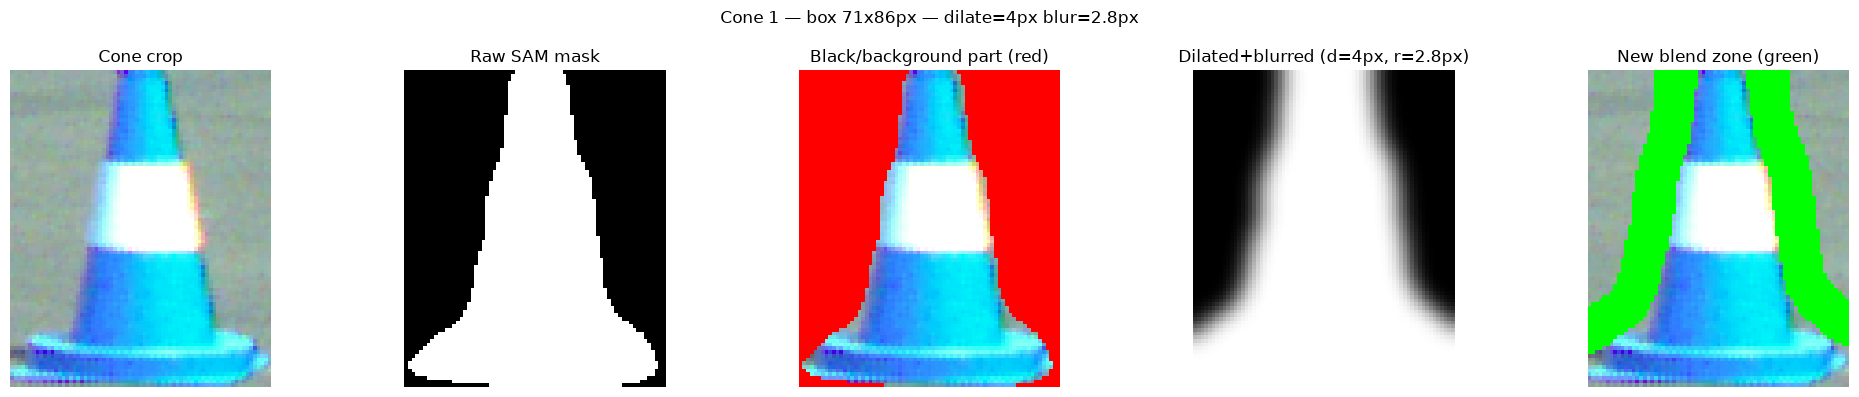

Saved debug_bgblend_cone1.png


In [38]:
import json
import numpy as np
import cv2
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

IMAGE_NAME = "amz_00820.png"
IN_DIR = "masks"
CONE_INDEX = 1

DILATE_FRAC = 0.05
BLUR_FRAC = 0.04

with open(f"{IN_DIR}/{IMAGE_NAME}_metadata.json") as f:
    meta = json.load(f)

cone = meta["cones"][CONE_INDEX]
box = tuple(cone["box"])
x0, y0, x1, y1 = box
box_size = min(x1 - x0, y1 - y0)

image = Image.open(f"Images/{meta['image_name']}").convert("RGB")
crop = image.crop(box)

raw_mask = Image.open(f"{IN_DIR}/{meta['image_name']}_mask_{CONE_INDEX}.png")
raw_np = np.array(raw_mask)

dilate_px = max(1, round(box_size * DILATE_FRAC))
blur_radius = max(0.5, box_size * BLUR_FRAC)

kernel = np.ones((dilate_px * 2 + 1, dilate_px * 2 + 1), np.uint8)
dilated_np = cv2.dilate(raw_np, kernel)
dilated_mask = Image.fromarray(dilated_np, mode="L")
feathered_mask = dilated_mask.filter(ImageFilter.GaussianBlur(blur_radius))

# --- Black-part coverage: everything the raw mask calls background ---
black_part = (raw_np == 0).astype(np.uint8) * 255
black_overlay = np.array(crop).copy()
black_overlay[black_part > 0] = [255, 0, 0]  # red = black/background region

# --- Blend zone with the new dilate+blur approach ---
feathered_np = np.array(feathered_mask)
blend_zone = ((feathered_np > 5) & (feathered_np < 250)).astype(np.uint8) * 255
blend_overlay = np.array(crop).copy()
blend_overlay[blend_zone > 0] = [0, 255, 0]  # green = blend zone (should be outside cone only)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(crop); axes[0].set_title("Cone crop")
axes[1].imshow(raw_mask, cmap="gray"); axes[1].set_title("Raw SAM mask")
axes[2].imshow(black_overlay); axes[2].set_title("Black/background part (red)")
axes[3].imshow(feathered_mask, cmap="gray"); axes[3].set_title(f"Dilated+blurred (d={dilate_px}px, r={blur_radius:.1f}px)")
axes[4].imshow(blend_overlay); axes[4].set_title("New blend zone (green)")

for ax in axes:
    ax.axis("off")

fig.suptitle(f"Cone {CONE_INDEX} — box {x1-x0}x{y1-y0}px — dilate={dilate_px}px blur={blur_radius:.1f}px")
plt.tight_layout()
plt.savefig(f"debug_bgblend_cone{CONE_INDEX}.png", dpi=150)
plt.show()
print(f"Saved debug_bgblend_cone{CONE_INDEX}.png")

In [1]:
import torch
from sdnq import SDNQConfig
from diffusers import DiffusionPipeline
from PIL import Image

pipe = DiffusionPipeline.from_pretrained(
    "Disty0/FLUX.2-klein-4B-SDNQ-4bit-dynamic",
    dtype=torch.bfloat16,
    device_map="cuda"
)

CROP_PATH = "cropped_test.png"  # change to your file
crop = Image.open(CROP_PATH).convert("RGB")

PROMPT = (
    "This image shows multiple traffic cones next to each other. "
    "For each cone, remove its colored stripe pattern and make it a single, solid, "
    "uniform color matching its own base color, from top to base. "
    "Keep each cone's shape, position, lighting, shadow, and texture, and the background "
    "exactly the same — only flatten each cone's stripes into its own solid color, "
    "without blending the different cones' colors into each other."
)

orig_w, orig_h = crop.size
scale = max(1, 256 // max(orig_w, orig_h))
work_image = crop.resize((orig_w * scale, orig_h * scale), Image.LANCZOS)

result = pipe(
    prompt=PROMPT,
    image=work_image,
    guidance_scale=2.5,
    num_inference_steps=10,
    generator=torch.manual_seed(0)
).images[0]

result = result.resize((orig_w, orig_h), Image.LANCZOS)
result.save("test_edited_crop.png")
print("Saved test_edited_crop.png")

SDNQ: Torch Compile is not available. Falling back to PyTorch Eager mode.
SDNQ: OpenVINO MM kernels are not available! Falling back to PyTorch Eager kernels for CPU device. Error message: No module named 'openvino'
SDNQ: Triton MM kernels are not available! Falling back to PyTorch Eager kernels. Error message: No module named 'triton'
SDNQ: Triton Scaled MM kernels are not available! Falling back to PyTorch Eager kernels. Error message: No module named 'triton'
c:\Users\seusa\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0913 22:37:14.011000 34156 site-packages\torch\utils\_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and wil

Saved test_edited_crop.png
